<a href="https://colab.research.google.com/github/jempio/cog403-final-project/blob/main/COG403_Project_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Appraisal-Text Fusion for Emotion Classification
**Authors**  
Justin Li - `jstn.li@mail.utoronto.ca`  
Tiana Chan - `tiana.chan@mail.utoronto.ca`


## 1) Research Question and Hypotheses

### Research Question
Does combining text and appraisal information to predict emotion outperform using either source alone?

### Hypotheses

**H1. Appraisal-only information is a predictor of emotion.**  
The seven appraisal dimensions (Attention, Certainty, Effort, Pleasant, Responsibility, Control, Circumstance) are theoretically tied to emotional experience, so a simple classifier trained only on these values is expected to perform above chance.

**H2. Text-only features should also perform well.**  
A TF-IDF representation of the sentence paired with logistic regression should provide a strong baseline for emotion classification.

**H3. Fusion should outperform single-source models.**  
Combining text features with appraisal features should produce better **macro F1** than either text-only or appraisal-only models, because the model can use both semantic content and structured affective cues.

## 2) Methods

### 2.1) Dataset
We use the Appraisal enISEAR dataset, where each instance contains:

- a sentence describing an emotional event
- an emotion class
- seven appraisal annotations

**Text input**  
The `Sentence` column is encoded with TF-IDF for a classical baseline

**Appraisal input**  
The seven appraisal columns are treated as a compact numeric feature vector:

- `Attention`
- `Certainty`
- `Effort`
- `Pleasant`
- `Responsibility`
- `Control`
- `Circumstance`

**Fusion**  
The text representation and appraisal vector are concatenated and passed to a classifier.

**Output**  
The target is the emotion label in `Prior_Emotion` (used here as the dataset's emotion-class column).

**Task**  
Single-label multiclass emotion classification across seven emotion categories.

### 2.2) Evaluation
We report:

- **Macro F1**
- **Weighted-F1**
- **Accuracy**

## 3) Data Cleaning

In [63]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from scipy.sparse import csr_matrix



In [64]:
TEXT_COL = "Sentence"
LABEL_COL = "Prior_Emotion"
APPRAISAL_COLS = [
    "Attention",
    "Certainty",
    "Effort",
    "Pleasant",
    "Responsibility",
    "Control",
    "Circumstance",
]

RANDOM_STATE = 42
TEST_SIZE = 0.20

In [65]:
data_path = "emotion_appraisal_corpus.tsv"

if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"Could not find {data_path}. Download the dataset and place it in the same folder as this notebook."
    )

raw_df = pd.read_csv(data_path, sep="\t")
print(f"Loaded dataset from: {data_path}")
print(f"Shape: {raw_df.shape}")
display(raw_df.head())

Loaded dataset from: emotion_appraisal_corpus.tsv
Shape: (1001, 10)


,Sentence_id,Prior_Emotion,Sentence,Attention,Certainty,Effort,Pleasant,Responsibility,Control,Circumstance
0,271,Fear,"I felt ... when my 2 year old broke her leg, a...",3,1,3,0,0,1,1
1,597,Shame,I felt ... one Christmas as one of our patient...,3,3,1,0,2,0,0
2,282,Guilt,I felt ... because I could not help a friend w...,1,3,0,0,3,2,1
3,171,Disgust,I felt ... when I read that hunters had killed...,2,3,0,0,0,0,0
4,509,Sadness,I felt ... when my Gran passed away.,2,2,2,0,0,0,3


In [66]:
# data cleaning
df = raw_df.copy()

# drop rows missing the text or emotion label
df = df.dropna(subset=[TEXT_COL, LABEL_COL])

# clean text and labels by converting to strings and stripping whitespace
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.title()

# then remove rows where the text becomes empty after stripping
df = df[df[TEXT_COL].str.len() > 0].copy()

for col in APPRAISAL_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=APPRAISAL_COLS)
df = df.drop_duplicates(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)

display(df.head())

,Sentence_id,Prior_Emotion,Sentence,Attention,Certainty,Effort,Pleasant,Responsibility,Control,Circumstance
0,271,Fear,"I felt ... when my 2 year old broke her leg, a...",3,1,3,0,0,1,1
1,597,Shame,I felt ... one Christmas as one of our patient...,3,3,1,0,2,0,0
2,282,Guilt,I felt ... because I could not help a friend w...,1,3,0,0,3,2,1
3,171,Disgust,I felt ... when I read that hunters had killed...,2,3,0,0,0,0,0
4,509,Sadness,I felt ... when my Gran passed away.,2,2,2,0,0,0,3


### 3.1) Exploratory Data Analysis

In [67]:
# quick eda
print("Dataset shape:", df.shape)

print("\nClass counts:")
print(df[LABEL_COL].value_counts())

df["text_len_words"] = df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))
print("\nText length summary (words):")
display(df["text_len_words"].describe())

Dataset shape: (999, 10)

Class counts:
Prior_Emotion
Fear       143
Shame      143
Guilt      143
Disgust    143
Anger      143
Sadness    142
Joy        142
Name: count, dtype: int64

Text length summary (words):


count    999.000000
mean      25.332332
std       19.908449
min        6.000000
25%       14.000000
50%       20.000000
75%       30.000000
max      270.000000
Name: text_len_words, dtype: float64

### 3.2) Test/Train Split

We use a stratified split so that the emotion-class distribution is preserved in both the training and test sets.  
We also encode the string labels into integer IDs for models that require numeric targets.

In [68]:
train_df, test_df = train_test_split(df, test_size=TEST_SIZE,random_state=RANDOM_STATE, stratify=df[LABEL_COL])

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df[LABEL_COL])
y_test = label_encoder.transform(test_df[LABEL_COL])

X_train_text = train_df[TEXT_COL].tolist()
X_test_text = test_df[TEXT_COL].tolist()

X_train_app = train_df[APPRAISAL_COLS].to_numpy(dtype=float)
X_test_app = test_df[APPRAISAL_COLS].to_numpy(dtype=float)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Classes:", list(label_encoder.classes_))

Train shape: (799, 11)
Test shape: (200, 11)
Classes: ['Anger', 'Disgust', 'Fear', 'Guilt', 'Joy', 'Sadness', 'Shame']


## 4) Models

### Helper Functions

In [69]:
from helper_functions import compare_text_models, compare_fusion_models

### 4.1) Baseline 1: Appraisal-only Sparse Logistic Regression

Standardize the appraisal inputs because they are numeric appraisal-count features on a shared scale.
We use L1-regularized logistic regression to encourage sparsity, meaning the model can shrink less useful coefficients toward zero.

In [70]:
app_scaler = StandardScaler()
X_train_app_scaled = app_scaler.fit_transform(X_train_app)
# use transform for test because its already scaled to the training data
X_test_app_scaled = app_scaler.transform(X_test_app)

appraisal = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=RANDOM_STATE)
appraisal.fit(X_train_app_scaled, y_train)
appraisal_predictions = appraisal.predict(X_test_app_scaled)

c:\Users\Justin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


### 4.2) Baseline 2: TF-IDF Sparse Logistic Regression

We convert each sentence into TF-IDF features using unigrams and bigrams. Since TF-IDF produces a high-dimensional representation, we initially considered L1-regularized logistic regression to encourage sparsity. However, after comparing L1 and L2 regularization, we found that L2 gave better performance on our dataset. This suggests that the useful lexical signal is distributed across many weak but informative text features, rather than concentrated in a small subset. Therefore, we use L2-regularized logistic regression for the final TF-IDF baseline.

In [71]:
# Convert text into TF-IDF features
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)

text_configs = [
    {"name": "L1, C=0.1", "penalty": "l1", "solver": "saga", "C": 0.1},
    {"name": "L2, C=0.1", "penalty": "l2", "solver": "saga", "C": 0.1},
    {"name": "L2, C=1.0", "penalty": "l2", "solver": "saga", "C": 1.0},
    {"name": "L1, C=1.0", "penalty": "l1", "solver": "saga", "C": 1.0},
    {"name": "L2, C=5.0", "penalty": "l2", "solver": "saga", "C": 5.0},
    {"name": "L1, C=5.0", "penalty": "l1", "solver": "saga", "C": 5.0},
]

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

text_results_df, text_preds_dict = compare_text_models(X_train_tfidf, y_train, X_test_tfidf, y_test, text_configs, random_state=RANDOM_STATE)

display(text_results_df)

,Model,Macro-F1,Weighted-F1,Accuracy
2,"L2, C=1.0",0.5076,0.5067,0.505
1,"L2, C=0.1",0.4833,0.4826,0.490
4,"L2, C=5.0",0.4800,0.4787,0.480
3,"L1, C=1.0",0.4602,0.4585,0.450
5,"L1, C=5.0",0.4071,0.4053,0.400
0,"L1, C=0.1",0.0362,0.0367,0.145


In [72]:
best_model_name = text_results_df.iloc[0]["Model"]
text_predictions = text_preds_dict[best_model_name]

print("Best text model:", best_model_name)

Best text model: L2, C=1.0


### 4.3) Main Model: TF-IDF + appraisal features

This model combines the text features with the appraisal features.

Before combining them, we want to:
- standardize the appraisal features
- convert them to a sparse matrix
- scale down the TF-IDF block using a weight

The TF-IDF representation has many more dimensions than the appraisal block, so scaling it down helps prevent the text features from dominating the fused model simply because there are so many of them.

In [73]:
from itertools import product

penalties = ["l1", "l2"]
Cs = [0.1, 1.0, 5.0]
text_weights = [0.10, 0.25, 0.50]

fusion_configs = [
    {
        "name": f"{penalty.upper()}_C{C}_TW{tw}",
        "penalty": penalty,
        "C": C,
        "text_weight": tw,
    }
    for penalty, C, tw in product(penalties, Cs, text_weights)
]

In [74]:
# Convert scaled appraisal features to sparse format for concatenation
X_train_app_sparse = csr_matrix(X_train_app_scaled)
X_test_app_sparse = csr_matrix(X_test_app_scaled)

fusion_results_df, fusion_preds_dict = compare_fusion_models(
    X_train_tfidf,
    X_test_tfidf,
    X_train_app_sparse,
    X_test_app_sparse,
    y_train,
    y_test,
    fusion_configs,
    random_state=RANDOM_STATE
)

In [75]:
for tw in [0.10, 0.25, 0.50]:
    print(f"Fusion results for Text Weight = {tw}")
    display(
        fusion_results_df[fusion_results_df["Text Weight"] == tw][
            ["Penalty", "C", "Macro-F1", "Weighted-F1", "Accuracy"]
        ].sort_values("Macro-F1", ascending=False).reset_index(drop=True)
    )

Fusion results for Text Weight = 0.1


,Penalty,C,Macro-F1,Weighted-F1,Accuracy
0,L2,5.0,0.6719,0.6718,0.685
1,L1,5.0,0.6719,0.6718,0.685
2,L1,1.0,0.6719,0.6718,0.685
3,L2,1.0,0.6675,0.6675,0.680
4,L2,0.1,0.6653,0.6651,0.680
5,L1,0.1,0.6543,0.6545,0.670


Fusion results for Text Weight = 0.25


,Penalty,C,Macro-F1,Weighted-F1,Accuracy
0,L1,5.0,0.6929,0.6926,0.705
1,L2,5.0,0.6877,0.6876,0.700
2,L1,1.0,0.6719,0.6718,0.685
3,L2,1.0,0.6663,0.6660,0.680
4,L2,0.1,0.6653,0.6651,0.680
5,L1,0.1,0.6543,0.6545,0.670


Fusion results for Text Weight = 0.5


,Penalty,C,Macro-F1,Weighted-F1,Accuracy
0,L2,5.0,0.7160,0.7160,0.725
1,L1,5.0,0.6929,0.6924,0.705
2,L2,1.0,0.6877,0.6876,0.700
3,L1,1.0,0.6719,0.6718,0.685
4,L2,0.1,0.6581,0.6578,0.675
5,L1,0.1,0.6543,0.6545,0.670


In [58]:
best_fusion_model_name = fusion_results_df.iloc[0]["Model"]
fused_prediction = fusion_preds_dict[best_fusion_model_name]

print("Best fusion model:", best_fusion_model_name)

Best fusion model: L2_C5.0_TW0.5


## 5. Evaluation

We evaluate each model using macro-F1, weighted-F1, and accuracy.

Macro-F1 is especially important here because it gives equal weight to each emotion class and better reflects class-by-class performance. Accuracy is also reported as a secondary overall measure.

In [76]:
# Overall metrics for each model
results_table = pd.DataFrame([
    {
        "Model": "Appraisal-only",
        "Macro-F1": f1_score(y_test, appraisal_predictions, average="macro"),
        "Weighted-F1": f1_score(y_test, appraisal_predictions, average="weighted"),
        "Accuracy": accuracy_score(y_test, appraisal_predictions),
    },
    {
        "Model": "TF-IDF Text-only",
        "Macro-F1": f1_score(y_test, text_predictions, average="macro"),
        "Weighted-F1": f1_score(y_test, text_predictions, average="weighted"),
        "Accuracy": accuracy_score(y_test, text_predictions),
    },
    {
        "Model": "TF-IDF + Appraisal Fusion",
        "Macro-F1": f1_score(y_test, fused_prediction, average="macro"),
        "Weighted-F1": f1_score(y_test, fused_prediction, average="weighted"),
        "Accuracy": accuracy_score(y_test, fused_prediction),
    },
])

results_table = results_table.round(4)

In [77]:
appraisal_report = pd.DataFrame(
    classification_report(
        y_test,
        appraisal_predictions,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0,
    )
).transpose().round(4)

text_report = pd.DataFrame(
    classification_report(
        y_test,
        text_predictions,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0,
    )
).transpose().round(4)

fusion_report = pd.DataFrame(
    classification_report(
        y_test,
        fused_prediction,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0,
    )
).transpose().round(4)


In [78]:
print("Overall Results")
display(results_table)

print("Appraisal-only Classification Report")
display(appraisal_report)

print("TF-IDF Text-only Classification Report")
display(text_report)

print("Fusion Classification Report")
display(fusion_report)

Overall Results


,Model,Macro-F1,Weighted-F1,Accuracy
0,Appraisal-only,0.6471,0.6466,0.675
1,TF-IDF Text-only,0.5076,0.5067,0.505
2,TF-IDF + Appraisal Fusion,0.7160,0.7160,0.725


Appraisal-only Classification Report


,precision,recall,f1-score,support
Anger,0.6316,0.8276,0.7164,29.000
Disgust,0.5000,0.3929,0.4400,28.000
Fear,0.6585,0.9310,0.7714,29.000
Guilt,0.5854,0.8276,0.6857,29.000
Joy,0.9655,1.0000,0.9825,28.000
Sadness,0.6818,0.5357,0.6000,28.000
Shame,0.8571,0.2069,0.3333,29.000
accuracy,0.6750,0.6750,0.6750,0.675
macro avg,0.6971,0.6745,0.6471,200.000
weighted avg,0.6969,0.6750,0.6466,200.000


TF-IDF Text-only Classification Report


,precision,recall,f1-score,support
Anger,0.4074,0.3793,0.3929,29.000
Disgust,0.5769,0.5357,0.5556,28.000
Fear,0.7200,0.6207,0.6667,29.000
Guilt,0.4118,0.4828,0.4444,29.000
Joy,0.6207,0.6429,0.6316,28.000
Sadness,0.5000,0.5357,0.5172,28.000
Shame,0.3448,0.3448,0.3448,29.000
accuracy,0.5050,0.5050,0.5050,0.505
macro avg,0.5117,0.5060,0.5076,200.000
weighted avg,0.5108,0.5050,0.5067,200.000


Fusion Classification Report


,precision,recall,f1-score,support
Anger,0.6053,0.7931,0.6866,29.000
Disgust,0.5357,0.5357,0.5357,28.000
Fear,0.8182,0.9310,0.8710,29.000
Guilt,0.6667,0.8276,0.7385,29.000
Joy,0.9655,1.0000,0.9825,28.000
Sadness,0.7273,0.5714,0.6400,28.000
Shame,0.8571,0.4138,0.5581,29.000
accuracy,0.7250,0.7250,0.7250,0.725
macro avg,0.7394,0.7247,0.7160,200.000
weighted avg,0.7393,0.7250,0.7160,200.000


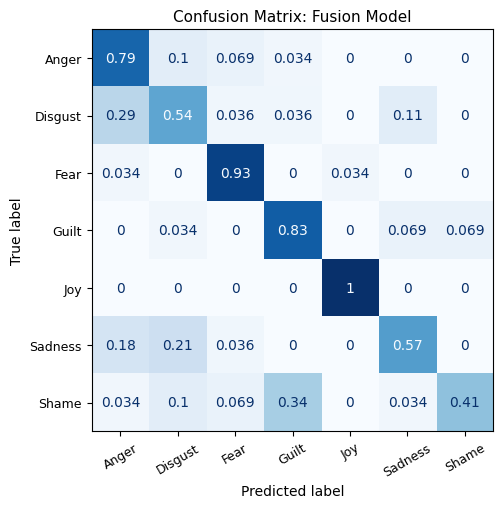

In [79]:
os.makedirs("figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(6.2, 5.0))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    fused_prediction,
    display_labels=label_encoder.classes_,
    normalize="true",
    xticks_rotation=30,
    cmap="Blues",
    ax=ax,
    colorbar=False,
)

ax.set_title("Confusion Matrix: Fusion Model", fontsize=11)
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout(pad=0.4)
plt.savefig("figures/confusion_matrix.pdf", bbox_inches="tight")
plt.savefig("figures/confusion_matrix.png", bbox_inches="tight")
plt.show()